In [83]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.decomposition import PCA

from perceptual_straightening.modules.elbo import ELBO

In [ ]:
# load data
save_params_path = Path('fitted_parameters')
monkey_id = 1
n_bins = 38

pkl_file = Path(save_params_path) / f"value_manifold_monkey{monkey_id}_{n_bins}bins_params.pkl"
with open(pkl_file, 'rb') as file:
    elbo = pickle.load(file)

bin_min = 0
bin_max = 38
bin_range = np.linspace(bin_min, bin_max, n_bins)

In [85]:
# compute PC-reduced perceptual locations
pca_fit = PCA(n_components=2)

pca_fit.fit(elbo.x.detach())
pc_fit = pca_fit.components_

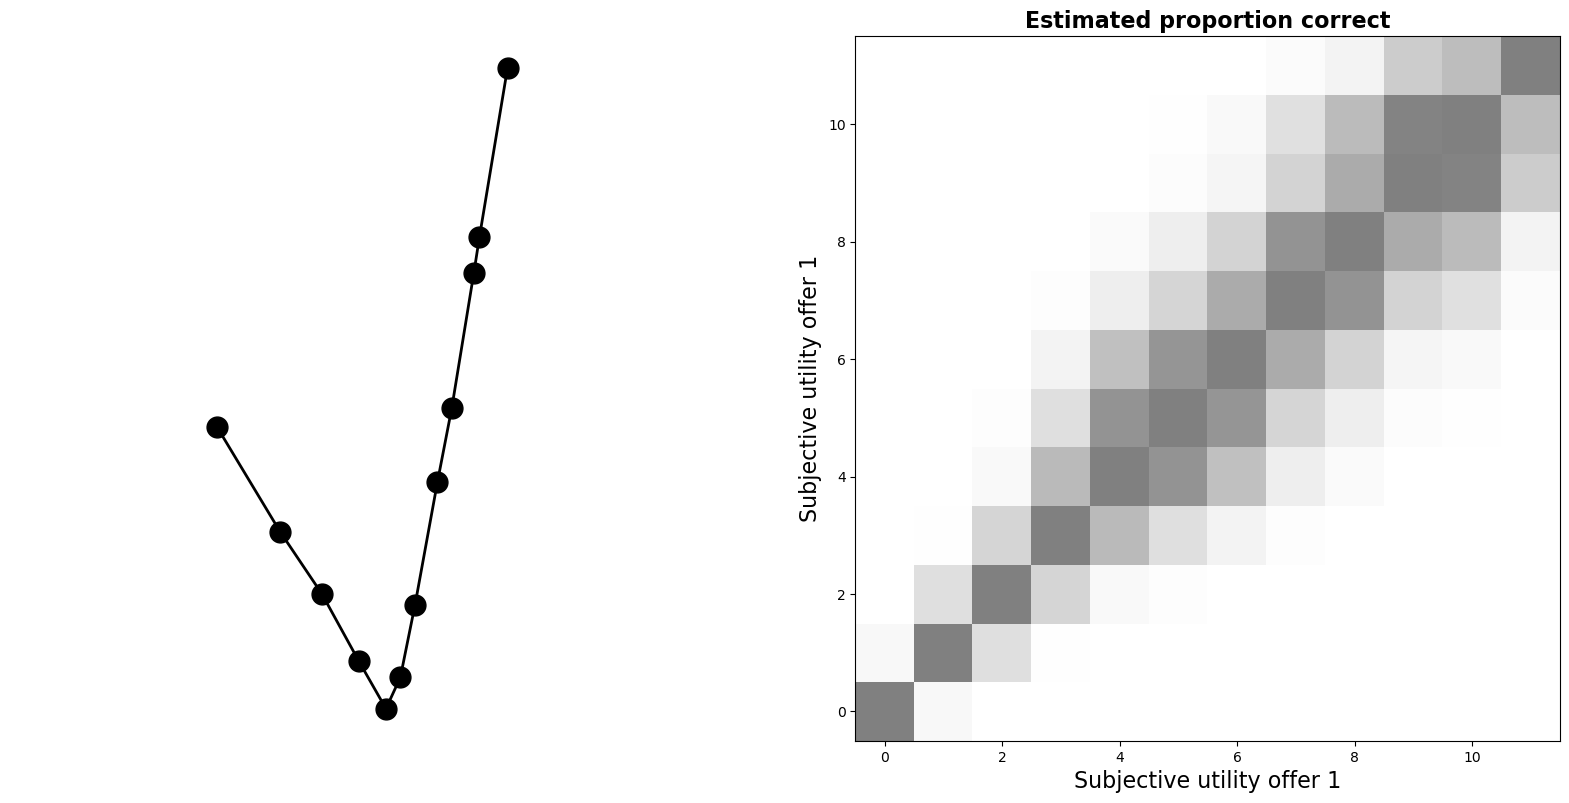

In [86]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
axs[0].plot(pc_fit[0, :], pc_fit[1, :], '-ko', markersize=15, linewidth=2)
axs[0].set_xlabel('PC 1')
axs[0].set_ylabel('PC 2')
axs[0].set_box_aspect(1)  
axs[0].set_aspect('equal') 
axs[0].set_axis_off()

# sns.heatmap(elbo.p.detach().numpy().squeeze(), xticklabels=np.round(bin_range), yticklabels=np.round(bin_range), ax=axs[1], cmap='gray', vmin=0, vmax=1)
axs[1].imshow(elbo.p.detach().numpy().squeeze(), cmap='gray', vmin=0, vmax=1)
axs[1].invert_yaxis()
axs[1].set_title('Estimated proportion correct', fontsize=16, fontweight='bold')
# axs[1].set_box_aspect(1)  
axs[1].set_aspect('equal') 
axs[1].set_xlabel('Subjective utility offer 1', fontsize=16)
axs[1].set_ylabel('Subjective utility offer 1', fontsize=16)
plt.show()

In [87]:
print(f'Inferred proportion correct: {np.mean(elbo.p.detach().numpy())}')
print(f'Mean curvature: {np.rad2deg(np.mean(elbo.mu_post_c.detach().numpy()))}')

Inferred proportion correct: 0.8867319822311401
Mean curvature: 0.20098162023426697


In [88]:
elbo.mu_post_c.detach().numpy()

array([-0.00127843, -0.00127846, -0.00127846,  0.00915175,  0.00771276,
        0.00320273,  0.00546566,  0.00503231,  0.00455711,  0.00379093])